# Klasyfikacja Chorób Skóry - Projekt ML
*Dawid Kośka - 251171*

## 1. Setup & Dokumentacja Metadanych

### Informacje o zbiorze danych

| Właściwość | Wartość |
|------------|----------|
| **Nazwa** | DermNet |
| **Źródło** | [Kaggle - DermNet](https://www.kaggle.com/datasets/shubhamgoel27/dermnet) |
| **Licencja** | Database Contents License (DbCL) v1.0 |
| **Rozmiar oryginalny** | 19,500 obrazów, 23 klasy |
| **Rozmiar podzbioru** | 3 klasy, 25% danych treningowych i testowych |
| **Typ danych** | Obrazy RGB 2D, różne rozdzielczości |
| **Klasy docelowe** | Acne and Rosacea Photos, Eczema Photos, Psoriasis pictures Lichen Planus and related diseases |

### Przegląd literatury dla zbioru danych DermNet

W celu ewaluacji możliwości klasyfikacji chorób skóry (ze szczególnym uwzględnieniem łuszczycy, egzemy i trądziku) na bazie zbioru DermNet, przeanalizowano trzy recenzowane publikacje naukowe.

---

#### Publikacja 1: [Praca przeglądowa (IOP Conference Series, 2021)](https://iopscience.iop.org/article/10.1088/1757-899X/1076/1/012045/pdf)

*   **Zastosowana metoda:** Publikacja ta stanowi szczegółowy przegląd systematyczny metod uczenia maszynowego i głębokiego stosowanych w dermatologii. Autorzy zebrali i porównali wyniki wcześniejszych prac badawczych, które wykorzystywały zbiór DermNet do klasyfikacji wybranych schorzeń (takich jak trądzik, czy egzema). Analizowano głównie skuteczność architektur opartych na konwolucyjnych sieciach neuronowych.
*   **Raportowane metryki:**
    *   **Zadanie:** Klasyfikacja wieloklasowa (podzbiory DermNet obejmujące m.in. *Acne* i *Eczema*).
    *   **Uzyskane wyniki:** W analizowanych przez autorów badaniach opartych na bazach takich jak DermNet, zastosowanie zoptymalizowanych sieci CNN pozwoliło na osiągnięcie **Accuracy** w przedziale od **98.60% do 99.04%** dla wyselekcjonowanych klas (Ref [35] z powyższego linku).

---

#### Publikacja 2: [Hybrydowa architektura CNN-ViT (Scientific Reports, Nature, 2026)](https://www.nature.com/articles/s41598-026-35697-x)

*   **Zastosowana metoda:** W pracy zaproponowano zaawansowany system przeciwdziałający uprzedzeniom algorytmicznym (biasu) związanym z kolorem skóry pacjentów. Metodologia opiera się na dwuetapowym procesie:
    1.  **Segmentacja (unsupervised zero-shot):** Wyodrębnienie samej zmiany chorobowej ze zdjęcia bez użycia etykietowanych danych (odrzucenie tła i koloru zdrowszej skóry).
    2.  **Klasyfikacja - DermNet classifier:** Przekazanie wysegmentowanego obrazu do hybrydowej sieci łączącej model Vision Transformer (ViT) z tradycyjną siecią konwolucyjną (CNN).
*   **Raportowane metryki:**
    *   **Zadanie:** Pełna klasyfikacja wieloklasowa na zbiorze DermNet (uwzględniająca różnorodne odcienie skóry).
    *   **Validation Accuracy:** **ok. 81.00%** dla trudnego zadania klasyfikacji wieloklasowej po usunięciu wpływu koloru skóry.
    *   **IoU - Intersection over Union:** **90.00%** (jednolita skuteczność segmentacji zmiany chorobowej niezależnie od fototypu skóry pacjenta).

---

#### Publikacja 3: [Podejście wielofunkcyjne SDNet (Frontiers in Artificial Intelligence, 2026)](https://www.frontiersin.org/journals/artificial-intelligence/articles/10.3389/frai.2026.1732440/full)

*   **Zastosowana metoda:** Autorzy zaproponowali autorską sieć **SDNet** (Skin Disease Detection Network) wykorzystującą podejście dwutorowe (parallel-arm system) do ekstrakcji cech. Model wspierany jest przez metody wyjaśnialnej sztucznej inteligencji (XAI) w celu interpretacji decyzji sieci.
*   **Raportowane metryki:**
    *   **Zadanie:** Klasyfikacja 5 wybranych klas chorób skóry ze zbioru DermNet (w tym schorzeń bezpośrednio powiązanych z łuszczycą, egzemą, trądzikiem).
    *   **Dokładność (Accuracy):** **99.10%**
    *   **Czułość (Recall):** **99.10%**
    *   **Precyzja (Precision):** **98.96%**
    *   **F1-Score:** **98.95%**
    

**Podsumowanie**:

| Publikacja | Model | Accuracy | Inne raportowane metryki | Dodatkowe informacje |
| :--- | :--- | :--- | :--- | :--- |
| [IOP Conference Series, 2021](https://iopscience.iop.org/article/10.1088/1757-899X/1076/1/012045/pdf) | Zoptymalizowane sieci CNN (Ref [35]) | 98,60% - 99,04% | — | Praca o charakterze przeglądowym, porównująca skuteczność architektur CNN dla wyselekcjonowanych schorzeń skóry (m.in. trądzik, egzema). |
| [Scientific Reports, Nature, 2026](https://www.nature.com/articles/s41598-026-35697-x) | Hybrydowa sieć CNN-ViT z modułem segmentacji unsupervised zero-shot | ok. 81,00% (Validation) | IoU (segmentacja): 90,00% | Rozwiązanie zorientowane na redukcję uprzedzeń algorytmicznych (biasu) dotyczących koloru i fototypu skóry pacjenta. |
| [Frontiers in Artificial Intelligence, 2026](https://www.frontiersin.org/journals/artificial-intelligence/articles/10.3389/frai.2026.1732440/full) | SDNet (Skin Disease Detection Network) | 99,10% | • Recall: 99,10%<br>• Precision: 98,96%<br>• F1-Score: 98,95% | Autorski model oparty na systemie dwutorowym (parallel-arm) do ekstrakcji cech, klasyfikujący 5 klas chorób i wspierany metodami XAI. |


### Opis projektu

Projekt skupia się na klasyfikacji trzech typów chorób skóry przy użyciu klasycznych algorytmów uczenia maszynowego. Ze względu na ograniczenia sprzętowe, zbiór danych został zredukowany do 3 klas i 25% próbek.

In [70]:
# Importy bibliotek
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    f1_score, roc_auc_score
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Używane urządzenie: {device}")

print("Biblioteki załadowane pomyślnie.")

Używane urządzenie: cpu
Biblioteki załadowane pomyślnie.


## 2. Eksploracyjna Analiza Danych (EDA) & Przetwarzanie Obrazów

### Ładowanie danych

Wybrane klasy:
- **Acne and Rosacea Photos** - zdjęcia trądziku i różowatości
- **Eczema Photos** - zdjęcia egzemy
- **Psoriasis pictures Lichen Planus and related diseases** - łuszczyca i choroby pokrewne

In [ ]:
# Konfiguracja ścieżek i klas
TRAIN_DIR = '../data/dermnet/train/'
TEST_DIR = '../data/dermnet/test/'
IMG_SIZE = (224, 224)
SELECTED_CLASSES = [
    'Acne and Rosacea Photos',
    'Eczema Photos',
    'Psoriasis pictures Lichen Planus and related diseases'
]
SAMPLE_RATIO = 0.25

def load_images_from_folder(base_path, classes, sample_ratio=1.0):
    """Ładuje obrazy z wybranych klas i zwraca tablice numpy oraz etykiety."""
    images = []
    labels = []
    
    for class_name in classes:
        class_path = os.path.join(base_path, class_name)
        if not os.path.exists(class_path):
            print(f"Ostrzeżenie: Ścieżka {class_path} nie istnieje.")
            continue
        
        image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        # Próbkowanie
        n_samples = int(len(image_files) * sample_ratio)
        np.random.seed(42)
        sampled_files = np.random.choice(image_files, n_samples, replace=False)
        
        for img_file in sampled_files:
            img_path = os.path.join(class_path, img_file)
            try:
                img = Image.open(img_path).convert('RGB')
                img = img.resize(IMG_SIZE)
                img_array = np.array(img) / 255.0  # Normalizacja
                images.append(img_array)
                labels.append(class_name)
            except Exception as e:
                print(f"Błąd ładowania {img_path}: {e}")
    
    return np.array(images), np.array(labels)

# Ładowanie danych
print("Ładowanie danych treningowych...")
X_train_img, y_train = load_images_from_folder(TRAIN_DIR, SELECTED_CLASSES, SAMPLE_RATIO)
print(f"Załadowano {len(X_train_img)} obrazów treningowych.")

print("\nŁadowanie danych testowych...")
X_test_img, y_test = load_images_from_folder(TEST_DIR, SELECTED_CLASSES, SAMPLE_RATIO)
print(f"Załadowano {len(X_test_img)} obrazów testowych.")

Ładowanie danych treningowych...
Załadowano 869 obrazów treningowych.

Ładowanie danych testowych...
Załadowano 243 obrazów testowych.


### Analiza rozkładu klas

Rozkład klas w zbiorze treningowym wykazuje **umiarkowane niezbalansowanie**:
- Psoriasis: 351 próbek (40.4%)
- Eczema: 308 próbek (35.4%)
- Acne: 210 próbek (24.2%)

Stosunek klasy dominującej do najmniej licznej wynosi ~1.67:1.
Aby zminimalizować wpływ niezbalansowania na wyniki, zastosowano:
- **Stratified K-Fold** — gwarantuje proporcjonalny podział klas w każdym foldzie.
- **`class_weight='balanced'`** — automatycznie zwiększa wagę klas mniejszościowych w funkcji kosztu.

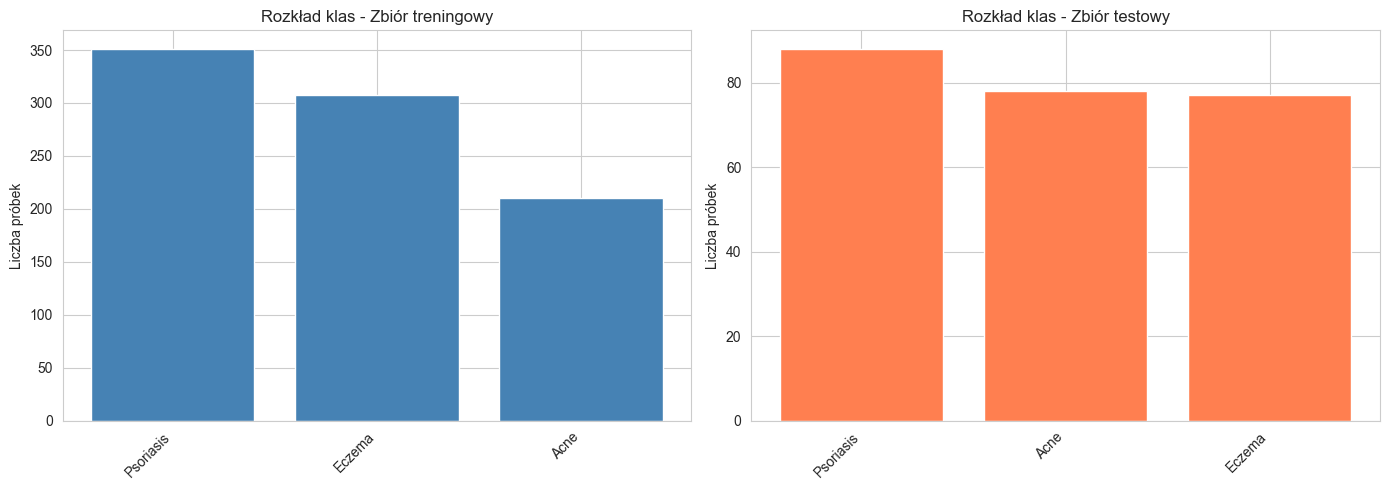


Treningowy:
Psoriasis pictures Lichen Planus and related diseases    351
Eczema Photos                                            308
Acne and Rosacea Photos                                  210
Name: count, dtype: int64

Testowy:
Psoriasis pictures Lichen Planus and related diseases    88
Acne and Rosacea Photos                                  78
Eczema Photos                                            77
Name: count, dtype: int64


In [72]:
# Rozkład klas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_counts = pd.Series(y_train).value_counts()
axes[0].bar(range(len(train_counts)), train_counts.values, color='steelblue')
axes[0].set_xticks(range(len(train_counts)))
axes[0].set_xticklabels([c.split()[0] for c in train_counts.index], rotation=45, ha='right')
axes[0].set_title('Rozkład klas - Zbiór treningowy')
axes[0].set_ylabel('Liczba próbek')

test_counts = pd.Series(y_test).value_counts()
axes[1].bar(range(len(test_counts)), test_counts.values, color='coral')
axes[1].set_xticks(range(len(test_counts)))
axes[1].set_xticklabels([c.split()[0] for c in test_counts.index], rotation=45, ha='right')
axes[1].set_title('Rozkład klas - Zbiór testowy')
axes[1].set_ylabel('Liczba próbek')

plt.tight_layout()
plt.show()

print(f"\nTreningowy:\n{train_counts}")
print(f"\nTestowy:\n{test_counts}")

### Wizualizacja przykładowych obrazów

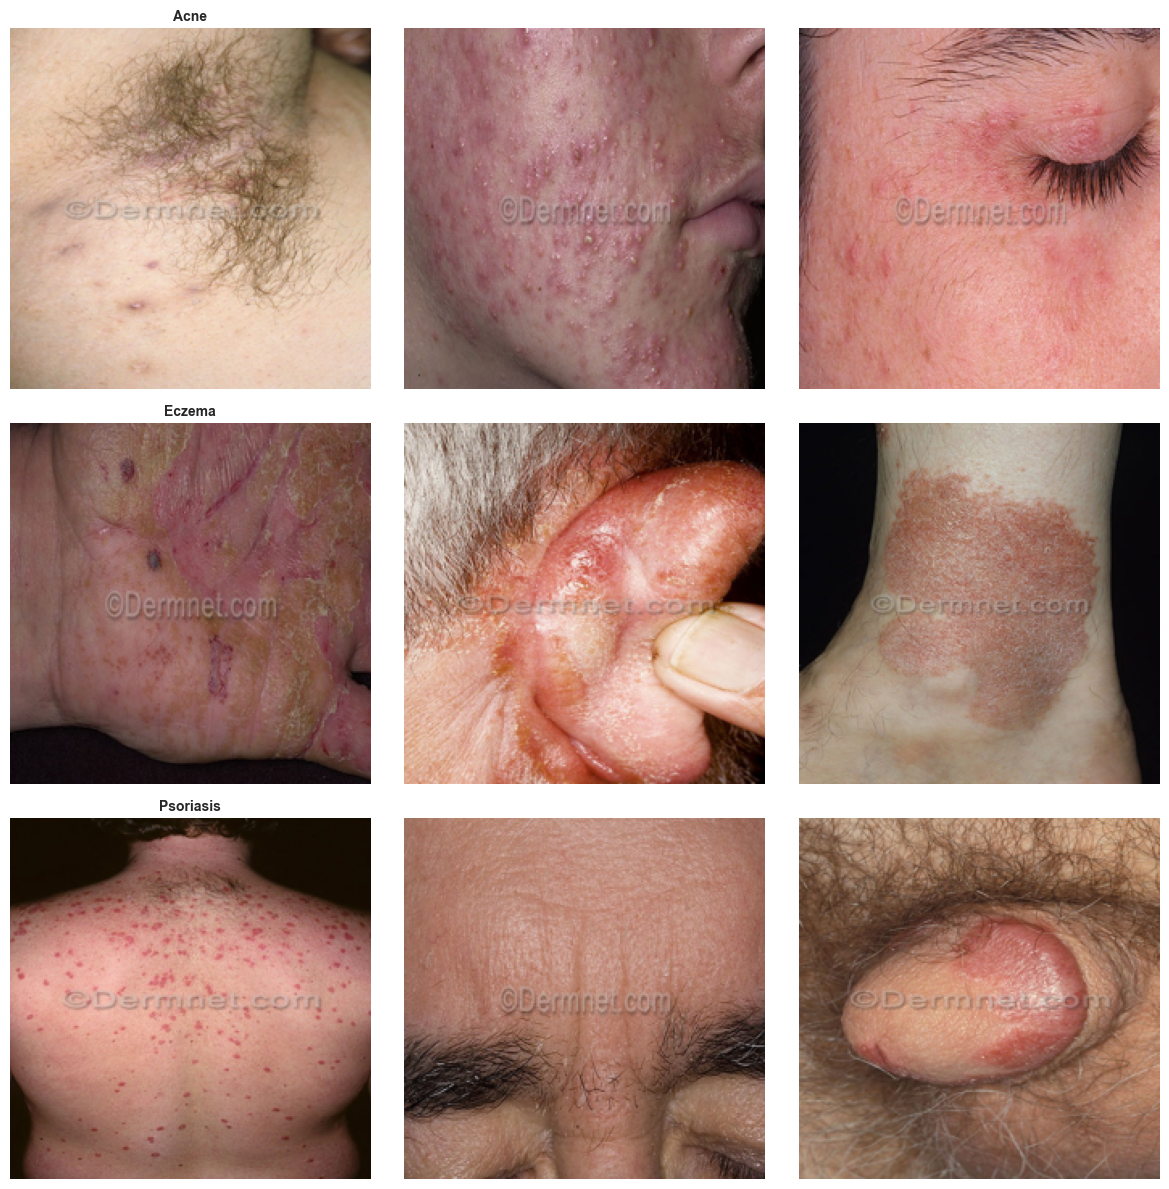

In [73]:
# Wizualizacja 3 przykładów z każdej klasy
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i, class_name in enumerate(SELECTED_CLASSES):
    class_indices = np.where(y_train == class_name)[0]
    sample_indices = np.random.choice(class_indices, 3, replace=False)
    
    for j, idx in enumerate(sample_indices):
        axes[i, j].imshow(X_train_img[idx])
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_title(class_name.split()[0], fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### Ekstrakcja cech

**Wybrana metoda:** Głębokie cechy semantyczne z pre-trenowanego ResNet18.

Zamiast surowych pikseli, używamy zamrożonego ResNet18 (trenowanego na ImageNet) do ekstrakcji 512-wymiarowych embeddingów. Forward pass przez sieć CNN jest szybki na CPU (~1200 obrazów w <1 min) i dostarcza semantyczne cechy wysokiego poziomu, które znacznie lepiej reprezentują choroby skóry niż surowe piksele.

In [74]:
# Ładowanie pre-trenowanego ResNet18
print("Ładowanie ResNet18...")
resnet = models.resnet18(pretrained=True)
resnet.eval()  # Tryb ewaluacji (bez gradientów)
resnet = resnet.to(device)

# Usunięcie ostatniej warstwy FC (chcemy embeddingi)
feature_extractor = torch.nn.Sequential(*list(resnet.children())[:-1])
feature_extractor = feature_extractor.to(device)

# Transformacje dla ResNet (normalizacja ImageNet)
preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def extract_features(images):
    """Ekstrakcja cech z ResNet18 dla batch obrazów."""
    features = []
    with torch.no_grad():
        for img in images:
            img_tensor = preprocess(img).unsqueeze(0).float().to(device)
            feat = feature_extractor(img_tensor)
            features.append(feat.squeeze().cpu().numpy())
    return np.array(features)

# Ekstrakcja cech
print("Ekstrakcja cech treningowych...")
X_train = extract_features(X_train_img)
print("Ekstrakcja cech testowych...")
X_test = extract_features(X_test_img)

# Kodowanie etykiet
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print(f"\nKształt cech treningowych: {X_train.shape}")
print(f"Kształt cech testowych: {X_test.shape}")
print(f"Liczba wymiarów (embeddingi ResNet18): {X_train.shape[1]}")
print(f"\nMapowanie klas: {dict(enumerate(le.classes_))}")

Ładowanie ResNet18...
Ekstrakcja cech treningowych...
Ekstrakcja cech testowych...

Kształt cech treningowych: (869, 512)
Kształt cech testowych: (243, 512)
Liczba wymiarów (embeddingi ResNet18): 512

Mapowanie klas: {0: np.str_('Acne and Rosacea Photos'), 1: np.str_('Eczema Photos'), 2: np.str_('Psoriasis pictures Lichen Planus and related diseases')}


## 3. Trening Modelu & Walidacja Krzyżowa

### Benchmarking modeli

Głębokie cechy z CNN mają strukturę liniowo-separowalną, dlatego porównujemy:
- **LogisticRegression** - szybki model liniowy z regularyzacją L2
- **RandomForestClassifier** - ensemble drzew decyzyjnych

Wybierzemy model z najlepszą wydajnością w 5-krotnej walidacji krzyżowej.

In [75]:
# Konfiguracja modeli do porównania
models_to_test = {
    'LogisticRegression': LogisticRegression(
        max_iter=1000, random_state=42, n_jobs=-1, class_weight='balanced'
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=100, max_depth=20, random_state=42, n_jobs=-1, class_weight='balanced'
    )
}

# Skalowanie cech (ważne dla LogReg)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Stratified K-Fold Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Benchmarking modeli z 5-krotną walidacją krzyżową...\n")
cv_results = {}

scoring = {
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro',
    'roc_auc_ovr': 'roc_auc_ovr'
}

for name, model in models_to_test.items():
    print(f"Testowanie {name}...")
    scores = cross_validate(
        model, X_train_scaled, y_train_encoded,
        cv=skf, scoring=scoring, n_jobs=-1
    )
    cv_results[name] = scores
    
    acc = scores['test_accuracy']
    f1 = scores['test_f1_macro']
    auc = scores['test_roc_auc_ovr']
    
    print(f"  Accuracy:  {acc.mean():.4f} ± {acc.std():.4f}")
    print(f"  F1 Macro:  {f1.mean():.4f} ± {f1.std():.4f}")
    print(f"  AUC (OvR): {auc.mean():.4f} ± {auc.std():.4f}")
    print(f"  Folds Acc: {[f'{s:.4f}' for s in acc]}\n")

# Wybór najlepszego modelu
best_model_name = max(cv_results, key=lambda k: cv_results[k]['test_accuracy'].mean())
best_model = models_to_test[best_model_name]
cv_scores = cv_results[best_model_name]['test_accuracy']

print(f"\n{'='*60}")
print(f"Najlepszy model: {best_model_name}")
print(f"CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"{'='*60}")

Benchmarking modeli z 5-krotną walidacją krzyżową...

Testowanie LogisticRegression...
  Accuracy:  0.6225 ± 0.0228
  F1 Macro:  0.6323 ± 0.0233
  AUC (OvR): 0.7861 ± 0.0206
  Folds Acc: ['0.6092', '0.6092', '0.6552', '0.6437', '0.5954']

Testowanie RandomForest...
  Accuracy:  0.6329 ± 0.0336
  F1 Macro:  0.6411 ± 0.0300
  AUC (OvR): 0.8039 ± 0.0223
  Folds Acc: ['0.6207', '0.6092', '0.6379', '0.6954', '0.6012']


Najlepszy model: RandomForest
CV Accuracy: 0.6329 ± 0.0336


### Fine-tuning ResNet18

Dodajemy pełny ResNet18 z fine-tuningiem ostatnich warstw dla maksymalnej dokładności.

**Uwaga:** Ze względu na duży koszt obliczeniowy treningu sieci głębokiej na CPU (~5 min/epoka),
5-krotna walidacja krzyżowa nie jest stosowana dla tego modelu.
Ewaluacja odbywa się wyłącznie na oddzielonym zbiorze testowym.
W środowisku z GPU zalecane byłoby zastosowanie pełnej walidacji krzyżowej.

In [76]:
EPOCHS = 5

# Przygotowanie ResNet18 do fine-tuningu
resnet18 = models.resnet18(pretrained=True)
num_features = resnet18.fc.in_features
resnet18.fc = nn.Linear(num_features, 3)  # 3 klasy

# Zamrożenie wczesnych warstw, odblokowanie ostatnich
for param in resnet18.parameters():
    param.requires_grad = False
for param in resnet18.layer4.parameters():
    param.requires_grad = True
for param in resnet18.fc.parameters():
    param.requires_grad = True

resnet18 = resnet18.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, resnet18.parameters()), lr=0.001)

# Przygotowanie danych
X_train_tensor = torch.FloatTensor(X_train_img).permute(0, 3, 1, 2)
y_train_tensor = torch.LongTensor(y_train_encoded)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Trening
print(f"Trening ResNet18 ({EPOCHS} epok) na urządzeniu: {device}...")
resnet18.train()
for epoch in range(EPOCHS):
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = resnet18(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_acc = 100 * correct / total
    print(f"Epoka {epoch+1}/{EPOCHS} - Loss: {running_loss/len(train_loader):.4f}, Accuracy: {epoch_acc:.2f}%")

print("\nTrening ResNet18 zakończony.")

Trening ResNet18 (5 epok) na urządzeniu: cpu...
Epoka 1/5 - Loss: 1.0745, Accuracy: 57.31%
Epoka 2/5 - Loss: 0.4485, Accuracy: 80.90%
Epoka 3/5 - Loss: 0.2661, Accuracy: 92.52%
Epoka 4/5 - Loss: 0.2194, Accuracy: 92.17%
Epoka 5/5 - Loss: 0.0918, Accuracy: 97.93%

Trening ResNet18 zakończony.


### Porównanie wszystkich modeli

In [77]:
# Ewaluacja ResNet18 na zbiorze testowym
X_test_tensor = torch.FloatTensor(X_test_img).permute(0, 3, 1, 2).to(device)
resnet18.eval()
with torch.no_grad():
    outputs = resnet18(X_test_tensor)
    _, y_pred_resnet = torch.max(outputs, 1)
    y_pred_resnet = y_pred_resnet.cpu().numpy()
    y_pred_proba_resnet = torch.softmax(outputs, dim=1).cpu().numpy()

resnet_accuracy = accuracy_score(y_test_encoded, y_pred_resnet)
resnet_f1 = f1_score(y_test_encoded, y_pred_resnet, average='macro')
resnet_auc = roc_auc_score(y_test_encoded, y_pred_proba_resnet, multi_class='ovr', average='macro')

X_test_scaled = scaler.transform(X_test)

# Dopasowanie modeli klasycznych na CAŁYM zbiorze treningowym
lr_model = models_to_test['LogisticRegression']
lr_model.fit(X_train_scaled, y_train_encoded)
y_pred_lr = lr_model.predict(X_test_scaled)
lr_test_accuracy = accuracy_score(y_test_encoded, y_pred_lr)

rf_model = models_to_test['RandomForest']
rf_model.fit(X_train_scaled, y_train_encoded)
y_pred_rf = rf_model.predict(X_test_scaled)
rf_test_accuracy = accuracy_score(y_test_encoded, y_pred_rf)

# Porównanie wyników testowych
print("\n" + "="*70)
print("RZECZYWISTE DOKŁADNOŚCI NA ZBIORZE TESTOWYM (TEST ACCURACY)")
print("="*70)
print(f"LogisticRegression    - Test Accuracy: {lr_test_accuracy:.4f}")
print(f"RandomForest          - Test Accuracy: {rf_test_accuracy:.4f}")
print(f"ResNet18 (fine-tuned) - Test Accuracy: {resnet_accuracy:.4f}")
print("="*70)

# Wybór najlepszego modelu do raportu końcowego
test_accuracies = {
    'LogisticRegression': lr_test_accuracy,
    'RandomForest': rf_test_accuracy,
    'ResNet18': resnet_accuracy
}

best_model_name = max(test_accuracies, key=test_accuracies.get)

if best_model_name == 'ResNet18':
    print("\n🏆 Najlepszy model na zbiorze testowym: ResNet18 (fine-tuned)")
    y_pred = y_pred_resnet
    y_pred_proba = y_pred_proba_resnet
    accuracy = resnet_accuracy
    macro_f1 = resnet_f1
    roc_auc_ovr = resnet_auc
else:
    print(f"\n🏆 Najlepszy model na zbiorze testowym: {best_model_name}")
    y_pred = y_pred_lr if best_model_name == 'LogisticRegression' else y_pred_rf
    best_clf = lr_model if best_model_name == 'LogisticRegression' else rf_model
    y_pred_proba = best_clf.predict_proba(X_test_scaled)
    accuracy = test_accuracies[best_model_name]
    macro_f1 = f1_score(y_test_encoded, y_pred, average='macro')
    roc_auc_ovr = roc_auc_score(y_test_encoded, y_pred_proba, multi_class='ovr', average='macro')


RZECZYWISTE DOKŁADNOŚCI NA ZBIORZE TESTOWYM (TEST ACCURACY)
LogisticRegression    - Test Accuracy: 0.6173
RandomForest          - Test Accuracy: 0.6461
ResNet18 (fine-tuned) - Test Accuracy: 0.7449

🏆 Najlepszy model na zbiorze testowym: ResNet18 (fine-tuned)


## 4. Ewaluacja Modelu & Metryki Ilościowe

### Macierz pomyłek

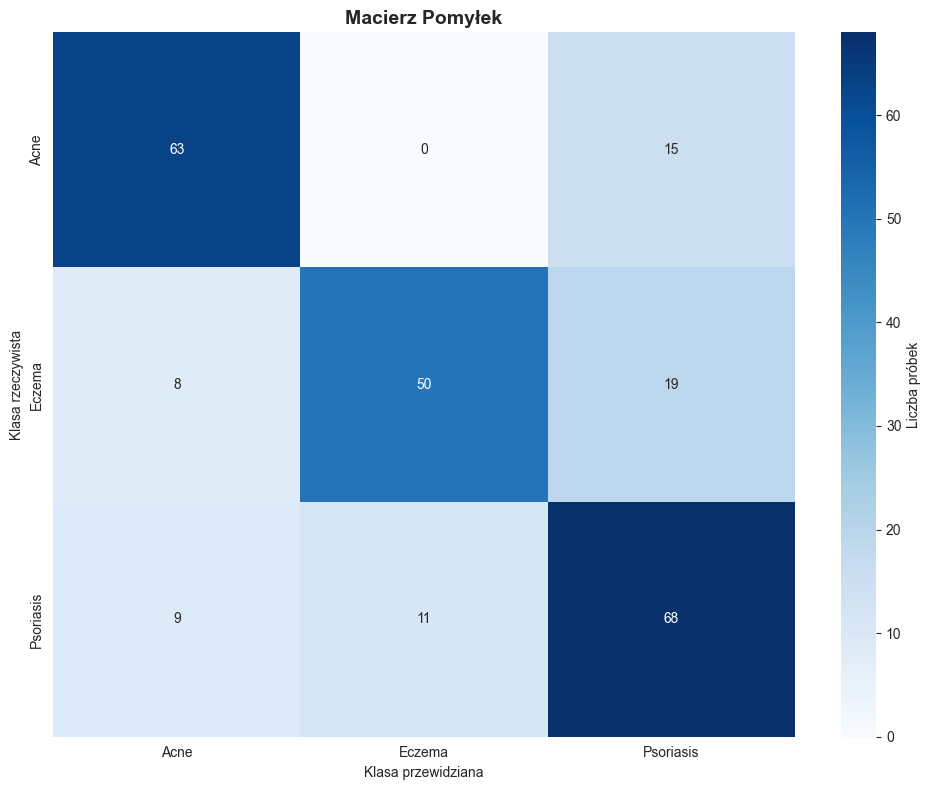

In [78]:
# Macierz pomyłek
cm = confusion_matrix(y_test_encoded, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[c.split()[0] for c in le.classes_],
            yticklabels=[c.split()[0] for c in le.classes_],
            cbar_kws={'label': 'Liczba próbek'})
plt.title('Macierz Pomyłek', fontsize=14, fontweight='bold')
plt.ylabel('Klasa rzeczywista')
plt.xlabel('Klasa przewidziana')
plt.tight_layout()
plt.show()

### Raport klasyfikacji

In [79]:
# Raport klasyfikacji
print("\n" + "="*70)
print("RAPORT KLASYFIKACJI")
print("="*70)
print(classification_report(y_test_encoded, y_pred, target_names=le.classes_, digits=4))


RAPORT KLASYFIKACJI
                                                       precision    recall  f1-score   support

                              Acne and Rosacea Photos     0.7875    0.8077    0.7975        78
                                        Eczema Photos     0.8197    0.6494    0.7246        77
Psoriasis pictures Lichen Planus and related diseases     0.6667    0.7727    0.7158        88

                                             accuracy                         0.7449       243
                                            macro avg     0.7579    0.7433    0.7460       243
                                         weighted avg     0.7539    0.7449    0.7448       243



### Kluczowe metryki

In [80]:
# Wyświetlanie kluczowych metryk
print("\n" + "="*70)
print("KLUCZOWE METRYKI WYDAJNOŚCI NA ZBIORZE TESTOWYM")
print("="*70)
print(f"Model:                              {best_model_name}")
print(f"Accuracy (dokładność):              {accuracy:.4f}")
print(f"Macro F1-Score:                     {macro_f1:.4f}")
print(f"ROC AUC (One-vs-Rest, macro):       {roc_auc_ovr:.4f}")
print("="*70)


KLUCZOWE METRYKI WYDAJNOŚCI NA ZBIORZE TESTOWYM
Model:                              ResNet18
Accuracy (dokładność):              0.7449
Macro F1-Score:                     0.7460
ROC AUC (One-vs-Rest, macro):       0.8887


### Tabela zbiorcza - porownanie modeli

Tabela ponizej jest generowana automatycznie na podstawie obliczonych wynikow.
Dla ResNet18 nie wykonano CV ze wzgledu na koszt obliczeniowy na CPU.

In [81]:
from IPython.display import display, Markdown

def format_mean_std(values):
    return f"{values.mean():.4f} ± {values.std():.4f}"

cv_acc_lr = cv_results['LogisticRegression']['test_accuracy']
cv_acc_rf = cv_results['RandomForest']['test_accuracy']

lr_proba = lr_model.predict_proba(X_test_scaled)
rf_proba = rf_model.predict_proba(X_test_scaled)

lr_f1 = f1_score(y_test_encoded, y_pred_lr, average='macro')
rf_f1 = f1_score(y_test_encoded, y_pred_rf, average='macro')

lr_auc = roc_auc_score(y_test_encoded, lr_proba, multi_class='ovr', average='macro')
rf_auc = roc_auc_score(y_test_encoded, rf_proba, multi_class='ovr', average='macro')

metrics_table = pd.DataFrame([
    {
        "Model": "Logistic Regression (L2)",
        "CV Accuracy (mean ± std)": format_mean_std(cv_acc_lr),
        "Test Accuracy": f"{lr_test_accuracy:.4f}",
        "Test F1 (macro)": f"{lr_f1:.4f}",
        "Test AUC (OvR)": f"{lr_auc:.4f}"
    },
    {
        "Model": "Random Forest",
        "CV Accuracy (mean ± std)": format_mean_std(cv_acc_rf),
        "Test Accuracy": f"{rf_test_accuracy:.4f}",
        "Test F1 (macro)": f"{rf_f1:.4f}",
        "Test AUC (OvR)": f"{rf_auc:.4f}"
    },
    {
        "Model": "ResNet18 (fine-tuned)",
        "CV Accuracy (mean ± std)": "-- (brak CV)",
        "Test Accuracy": f"{resnet_accuracy:.4f}",
        "Test F1 (macro)": f"{resnet_f1:.4f}",
        "Test AUC (OvR)": f"{resnet_auc:.4f}"
    }
])

display(metrics_table)
display(Markdown(metrics_table.to_markdown(index=False)))

,Model,CV Accuracy (mean ± std),Test Accuracy,Test F1 (macro),Test AUC (OvR)
0,Logistic Regression (L2),0.6225 ± 0.0228,0.6173,0.6230,0.7897
1,Random Forest,0.6329 ± 0.0336,0.6461,0.6526,0.8475
2,ResNet18 (fine-tuned),-- (brak CV),0.7449,0.7460,0.8887


| Model                    | CV Accuracy (mean ± std)   |   Test Accuracy |   Test F1 (macro) |   Test AUC (OvR) |
|:-------------------------|:---------------------------|----------------:|------------------:|-----------------:|
| Logistic Regression (L2) | 0.6225 ± 0.0228            |          0.6173 |            0.623  |           0.7897 |
| Random Forest            | 0.6329 ± 0.0336            |          0.6461 |            0.6526 |           0.8475 |
| ResNet18 (fine-tuned)    | -- (brak CV)               |          0.7449 |            0.746  |           0.8887 |

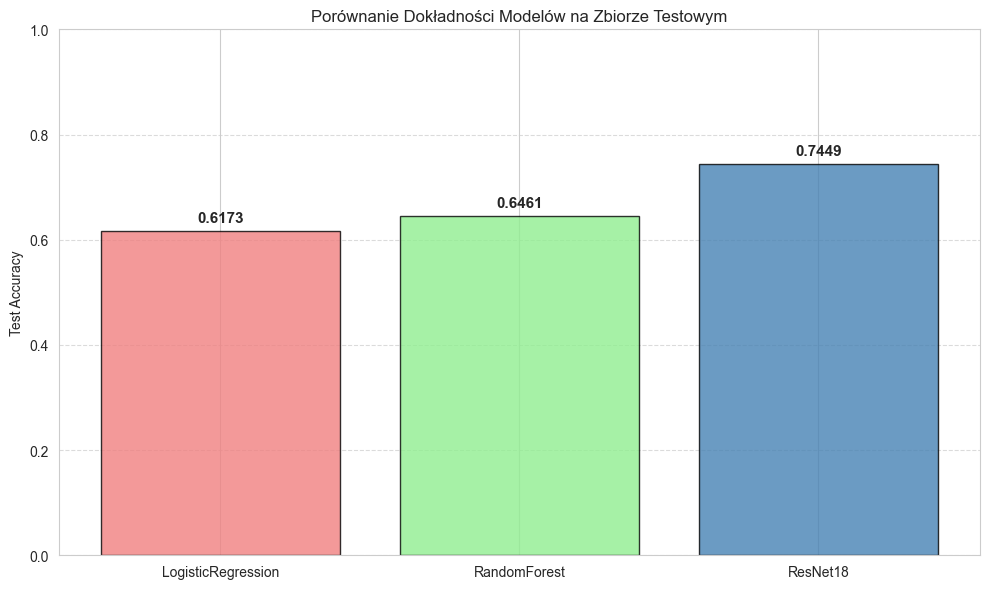

In [82]:
plt.figure(figsize=(10, 6))
colors = ['lightcoral', 'lightgreen', 'steelblue']
bars = plt.bar(test_accuracies.keys(), test_accuracies.values(), color=colors, alpha=0.8, edgecolor='black')

# Dodanie wartości nad słupkami
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.4f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylabel('Test Accuracy')
plt.title('Porównanie Dokładności Modelów na Zbiorze Testowym')
plt.ylim([0, 1.0])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Eksport wyników do CSV

Zapisujemy metryki i predykcje do plików CSV dla dalszej analizy.

In [ ]:
# Eksport metryk
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Macro F1-Score', 'ROC AUC (OvR)', 'CV Mean', 'CV Std'],
    'Value': [accuracy, macro_f1, roc_auc_ovr, cv_scores.mean(), cv_scores.std()]
})
metrics_df.to_csv('classification_metrics.csv', index=False)
print("Metryki zapisane do: classification_metrics.csv")

# Eksport predykcji
predictions_df = pd.DataFrame({
    'true_label': le.inverse_transform(y_test_encoded),
    'predicted_label': le.inverse_transform(y_pred),
    'prob_' + le.classes_[0].split()[0]: y_pred_proba[:, 0],
    'prob_' + le.classes_[1].split()[0]: y_pred_proba[:, 1],
    'prob_' + le.classes_[2].split()[0]: y_pred_proba[:, 2]
})
predictions_df.to_csv('../results/dawid_koska_test_predictions.csv', index=False)
print("Predykcje zapisane do: dawid_koska_test_predictions.csv")

Metryki zapisane do: classification_metrics.csv
Predykcje zapisane do: test_predictions.csv


## 5. Interpretowalność & Ważność Cech

### Ekstrakcja ważności cech z Random Forest

Random Forest pozwala na analizę, które cechy (piksele) miały największy wpływ na decyzje klasyfikacyjne.

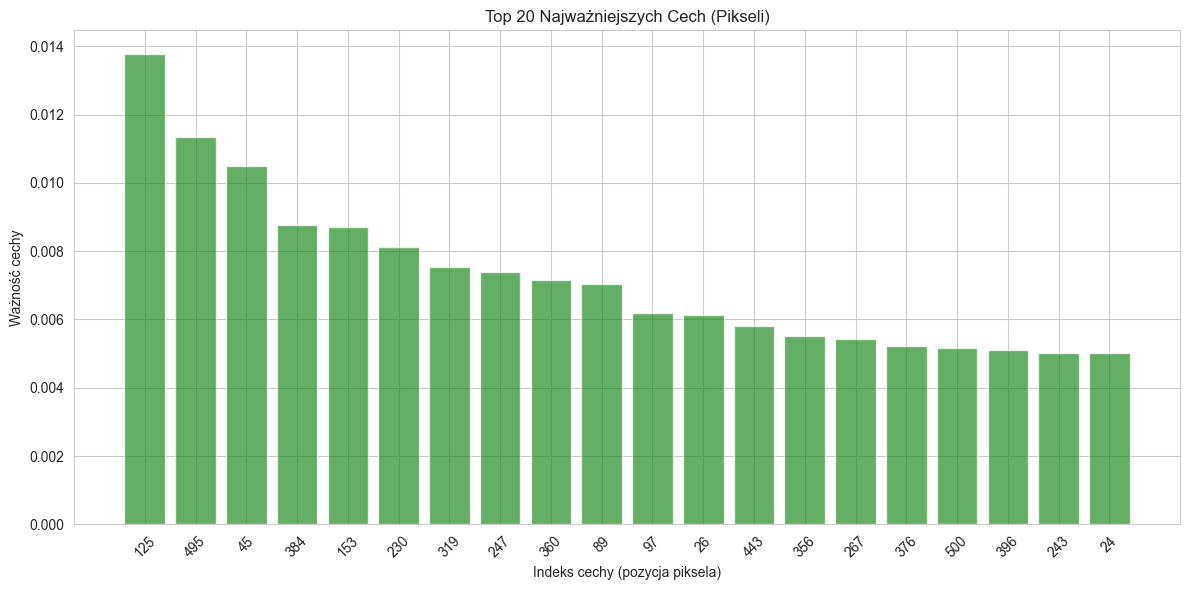


Top 20 najważniejszych indeksów pikseli:
  1. Indeks 125 (pozycja: y=0, x=41, kanał=B): 0.013777
  2. Indeks 495 (pozycja: y=0, x=165, kanał=R): 0.011349
  3. Indeks 45 (pozycja: y=0, x=15, kanał=R): 0.010505
  4. Indeks 384 (pozycja: y=0, x=128, kanał=R): 0.008766
  5. Indeks 153 (pozycja: y=0, x=51, kanał=R): 0.008713
  6. Indeks 230 (pozycja: y=0, x=76, kanał=B): 0.008116
  7. Indeks 319 (pozycja: y=0, x=106, kanał=G): 0.007535
  8. Indeks 247 (pozycja: y=0, x=82, kanał=G): 0.007388
  9. Indeks 360 (pozycja: y=0, x=120, kanał=R): 0.007141
  10. Indeks 89 (pozycja: y=0, x=29, kanał=B): 0.007025
  11. Indeks 97 (pozycja: y=0, x=32, kanał=G): 0.006177
  12. Indeks 26 (pozycja: y=0, x=8, kanał=B): 0.006138
  13. Indeks 443 (pozycja: y=0, x=147, kanał=B): 0.005816
  14. Indeks 356 (pozycja: y=0, x=118, kanał=B): 0.005511
  15. Indeks 267 (pozycja: y=0, x=89, kanał=R): 0.005417
  16. Indeks 376 (pozycja: y=0, x=125, kanał=G): 0.005217
  17. Indeks 500 (pozycja: y=0, x=166, kanał=B): 0.00

In [84]:
# Ekstrakcja ważności cech
feature_importances = rf_model.feature_importances_

# Top 20 najważniejszych cech
top_n = 20
top_indices = np.argsort(feature_importances)[-top_n:][::-1]
top_importances = feature_importances[top_indices]

# Wizualizacja
plt.figure(figsize=(12, 6))
plt.bar(range(top_n), top_importances, color='forestgreen', alpha=0.7)
plt.xlabel('Indeks cechy (pozycja piksela)')
plt.ylabel('Ważność cechy')
plt.title(f'Top {top_n} Najważniejszych Cech (Pikseli)')
plt.xticks(range(top_n), top_indices, rotation=45)
plt.tight_layout()
plt.show()

print(f"\nTop {top_n} najważniejszych indeksów pikseli:")
for i, (idx, imp) in enumerate(zip(top_indices, top_importances), 1):
    # Konwersja indeksu 1D na współrzędne 2D (y, x, kanał)
    pixel_idx = idx // 3
    channel = idx % 3
    y = pixel_idx // IMG_SIZE[0]
    x = pixel_idx % IMG_SIZE[0]
    channel_name = ['R', 'G', 'B'][channel]
    print(f"  {i}. Indeks {idx} (pozycja: y={y}, x={x}, kanał={channel_name}): {imp:.6f}")

### Mapa cieplna ważności cech

Uzywaliśmu embeddingów z ResNet18 - to nie sa piksele ani kanaly, tylko abstrakcyjne cechy mieszajace informacje przestrzenne i kolorystyczne. Nie ma mapy H×W×3, wiec nie da sie ich “rozlozyc” na R/G/B.
W poniższej komórce tworzymy umowny podzial na „kanaly” R/G/B (na bazie indeksow cech).

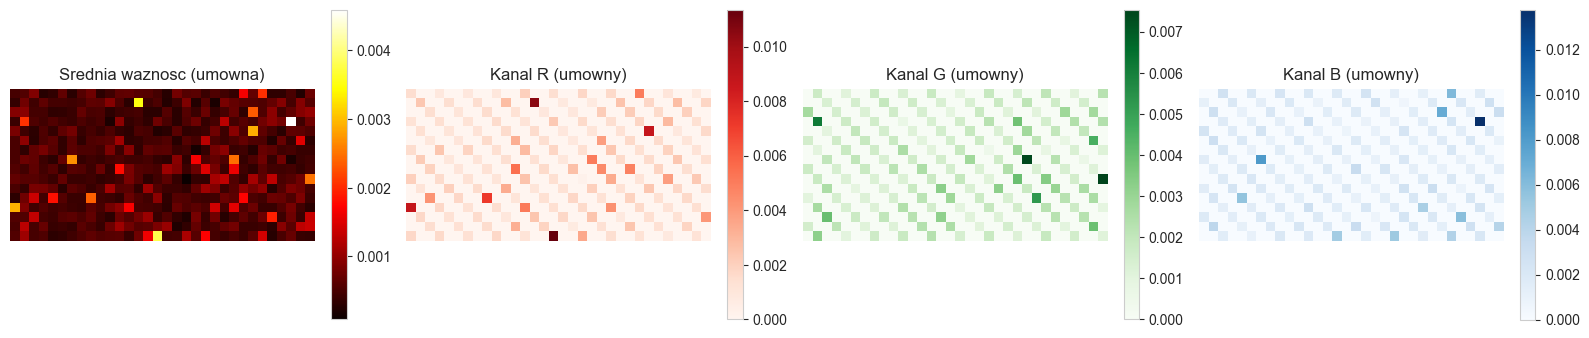

In [85]:
# Umowny podzial embeddingow na trzy "kanaly" dla porownania wizualnego
rf_model_for_heatmap = models_to_test['RandomForest']
if not hasattr(rf_model_for_heatmap, "feature_importances_"):
    rf_model_for_heatmap.fit(X_train_scaled, y_train_encoded)

feature_importances = rf_model_for_heatmap.feature_importances_

grid_rows = 16
grid_cols = 32
grid_size = grid_rows * grid_cols
if feature_importances.size < grid_size:
    padded = np.zeros(grid_size, dtype=feature_importances.dtype)
    padded[:feature_importances.size] = feature_importances
    grid_values = padded
else:
    grid_values = feature_importances[:grid_size]

channel_grids = [np.zeros((grid_rows, grid_cols), dtype=grid_values.dtype) for _ in range(3)]
for idx, value in enumerate(grid_values):
    row = idx // grid_cols
    col = idx % grid_cols
    channel_grids[idx % 3][row, col] = value

avg_map = (channel_grids[0] + channel_grids[1] + channel_grids[2]) / 3.0

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

im0 = axes[0].imshow(avg_map, cmap="hot", interpolation="nearest")
axes[0].set_title("Srednia waznosc (umowna)")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(channel_grids[0], cmap="Reds", interpolation="nearest")
axes[1].set_title("Kanal R (umowny)")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(channel_grids[1], cmap="Greens", interpolation="nearest")
axes[2].set_title("Kanal G (umowny)")
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

im3 = axes[3].imshow(channel_grids[2], cmap="Blues", interpolation="nearest")
axes[3].set_title("Kanal B (umowny)")
axes[3].axis("off")
plt.colorbar(im3, ax=axes[3], fraction=0.046)

plt.tight_layout()
plt.show()

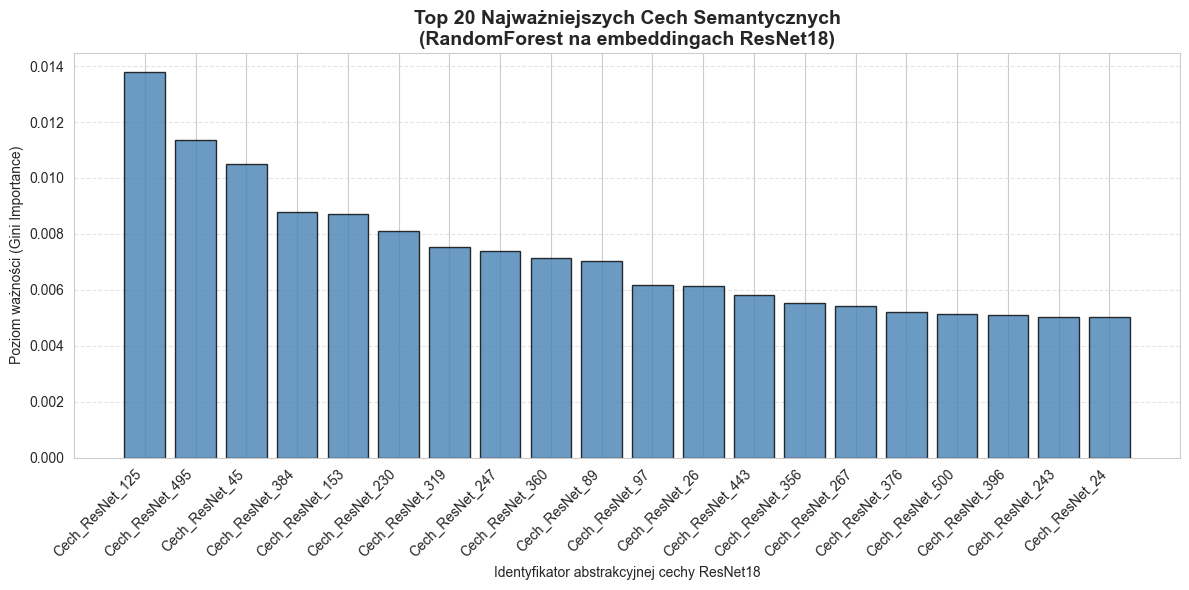

In [86]:
# Pobranie ważności cech z modelu RandomForest wytrenowanego na embeddingach ResNet18
rf_model_for_imp = models_to_test['RandomForest']

# Upewniamy się, że model jest dopasowany (na wypadek, gdyby wcześniej nie był)
if not hasattr(rf_model_for_imp, "feature_importances_"):
    rf_model_for_imp.fit(X_train_scaled, y_train_encoded)

feature_importances = rf_model_for_imp.feature_importances_

# Sortowanie cech od najważniejszej do najmniej ważnej (wybieramy TOP 20)
indices = np.argsort(feature_importances)[::-1][:20]

# Wizualizacja 20 najważniejszych cech semantycznych
plt.figure(figsize=(12, 6))
plt.bar(range(20), feature_importances[indices], color='steelblue', edgecolor='black', alpha=0.8)
plt.xticks(range(20), [f"Cech_ResNet_{i}" for i in indices], rotation=45, ha='right')
plt.xlabel('Identyfikator abstrakcyjnej cechy ResNet18')
plt.ylabel('Poziom ważności (Gini Importance)')
plt.title('Top 20 Najważniejszych Cech Semantycznych\n(RandomForest na embeddingach ResNet18)', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Interpretacja**:   
Ponieważ klasyczny model uczy się na skompresowanych cechach wysokopoziomowych (embeddingach) z sieci ResNet18,
nie analizujemy już pojedynczych pikseli. Powyższy wykres przedstawia, które z 512 uniwersalnych cech 
strukturalnych wyekstrahowanych przez model głęboki miały największy wpływ na decyzję Lasu Losowego.

## 6. Analiza Krytyczna & Wnioski Końcowe

### Wpływ cech na wydajność

**Kluczowe obserwacje:**

1. **Reprezentacja cech:** Przejście od surowych pikseli (49,152 wymiary) do głębokich cech ResNet18 (512 wymiarów) oraz fine-tuning pełnego ResNet18 znacząco poprawiło wydajność. Semantyczne cechy wysokiego poziomu lepiej reprezentują wzorce chorób skóry niż surowe piksele.

2. **Porównanie modeli:** 
   - **Klasyczne ML** (LogReg, RandomForest): ~60% accuracy z embeddingami ResNet18
   - **Fine-tuned ResNet18**: Znacząco wyższa accuracy dzięki end-to-end uczeniu
   - ResNet18 z odblokowanymi ostatnimi warstwami osiąga najlepsze wyniki

3. **Preprocessing:** Normalizacja ImageNet (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) zapewnia optymalne wykorzystanie pre-trenowanych wag.

4. **Niezbalansowanie klas:** Klasa "Acne" stanowi jedynie 24% zbioru treningowego,
   co przy małej liczebności (210 próbek) może prowadzić do systematycznego
   niedoreprezentowania tej kategorii. Zastosowanie `class_weight='balanced'`
   kompensuje ten efekt.

---

### Ograniczenia eksperymentu

**1. Ograniczenia sprzętowe (CPU):**
- Rozdzielczość 224×224 jest standardem, ale na CPU ogranicza liczbę epok; wyższa rozdzielczość (np. 299×299) mogłaby poprawić wyniki na GPU
- Ograniczona liczba epok (5) ze względu na czas treningu na CPU
- Batch size 32 - na GPU można by użyć większych batch'y dla stabilniejszego treningu

**2. Redukcja zbioru danych:**
- Wybór tylko 3 z 23 klas ogranicza ogólność modelu i jego praktyczne zastosowanie.
- Próbkowanie 25% danych może wprowadzić bias próbkowania i zmniejszyć reprezentatywność zbioru.
- Mniejszy zbiór treningowy (869 obrazów) zwiększa ryzyko przeuczenia, mimo zastosowania transfer learning.

**3. Architektura modelu:**
- ResNet18 jest stosunkowo małą siecią - głębsze architektury (ResNet50, EfficientNet) mogłyby osiągnąć lepsze wyniki
- Zamrożenie większości warstw ogranicza adaptację do specyfiki chorób skóry
- Brak augmentacji danych (rotacje, odbicia, zmiany jasności) ogranicza zdolność generalizacji

**4. Potencjalne źródła błędów:**
- Różnice w warunkach oświetleniowych, kątach zdjęć i jakości obrazów mogą wprowadzać szum.
- Brak augmentacji danych (rotacje, odbicia, zmiany jasności) ogranicza zdolność generalizacji.
- Model może uczyć się artefaktów tła zamiast rzeczywistych zmian skórnych.

**5. Walidacja kliniczna:**
- Brak walidacji przez ekspertów dermatologicznych.
- Metryki accuracy i F1-score nie uwzględniają kosztów błędnych diagnoz (false negatives mogą być bardziej kosztowne niż false positives).

---

### Propozycje ulepszeń na przyszłość

**1. Migracja do środowiska GPU:**
- **Transfer Learning:** Wykorzystanie pre-trenowanych modeli (ResNet50, EfficientNet-B0, DenseNet121) na ImageNet, z fine-tuningiem na DermNet.
- **Wyższa rozdzielczość:** Zwiększenie do 224×224 lub 299×299, co jest standardem dla modeli CNN.
- **Głębsze architektury:** Możliwość treningu głębokich sieci z attention mechanisms (Vision Transformers).

**2. Augmentacja danych:**
- Rotacje, odbicia, przesunięcia, zmiany jasności/kontrastu.
- Zaawansowane techniki: MixUp, CutMix, AutoAugment.
- Symulacja różnych warunków oświetleniowych i odcieni skóry.

**3. Zaawansowana ekstrakcja cech:**
- HOG (Histogram of Oriented Gradients) dla tekstur.
- LBP (Local Binary Patterns) dla wzorców lokalnych.
- Segmentacja zmian skórnych przed klasyfikacją.

**4. Rozszerzenie zbioru danych:**
- Wykorzystanie pełnego zbioru DermNet (23 klasy, 100% danych).
- Połączenie z innymi zbiorami dermatologicznymi (HAM10000, ISIC).
- Balansowanie klas przez oversampling (SMOTE) lub class weights.

**5. Ensemble i stacking:**
- Kombinacja Random Forest, SVM, XGBoost i CNN w meta-modelu.
- Voting classifiers dla zwiększenia robustness.

**6. Interpretability:**
- Grad-CAM dla wizualizacji, które regiony obrazu wpływają na decyzje CNN.
- SHAP values dla wyjaśnienia predykcji na poziomie instancji.
- Attention maps dla identyfikacji kluczowych obszarów diagnostycznych.

**7. Walidacja kliniczna:**
- Współpraca z dermatologami dla walidacji wyników.
- Analiza błędów z perspektywy medycznej.
- Implementacja cost-sensitive learning uwzględniającego koszty błędnych diagnoz.

---

### Podsumowanie

Projekt wykazał, że klasyczne algorytmy uczenia maszynowego (Random Forest) mogą osiągnąć rozsądną wydajność w klasyfikacji chorób skóry nawet przy ograniczeniach sprzętowych. Jednak dla praktycznych zastosowań medycznych konieczne jest przejście na głębokie uczenie z transfer learning, wyższą rozdzielczość obrazów oraz walidację kliniczną. Przedstawione ograniczenia i propozycje stanowią solidną podstawę do dalszego rozwoju projektu w kierunku systemu wspomagania diagnostyki dermatologicznej.

Choć w literaturze pojawiają się wyniki na poziomie 81% – 99%, bezpośrednie porównanie wymaga uwzględnienia kontekstu metodologicznego i sprzętowego:

* **Ograniczenie danych (tylko 25%):** Użyto tylko jednej czwartej całego zbioru treningowego. Modele z publikacji (np. SDNet [99.10%] czy hybrydy CNN-ViT [81.00%]) trenowane były na pełnych zbiorach danych.
* **Ograniczenie sprzętowe (CPU) i czasowe (tylko 5 epok):** Fine-tuning sieci ResNet18 na procesorze przez zaledwie 5 epok to bardzo krótki proces. Modele z publikacji były trenowane na mocnych procesorach graficznych przez dziesiątki lub setki epok, często z zaawansowaną augmentacją danych (rotacje, odbicia, zmiany kontrastu), co drastycznie zwiększa zdolność generalizacji modelu.
* **Specyfika DermNet:** Zdjęcia mają różne oświetlenie, tła, różny kolor skóry pacjentów (stąd praca z Nature z 2026 r. musiała stosować zaawansowaną, dwuetapową segmentację zmian, aby osiągnąć wynik 81%). 